# BanglaFinGPT — Agent-Agnostic Bilingual Financial QA for Bangla

Reproduction notebook for **"Agent-Agnostic Bilingual AI Chatbot for Financial Literacy
in Low-Resource Languages"**, run end-to-end on the released dataset
(`data/BanglaFinGPT_dataset.xlsx`, 10,412 QA pairs).

**What this notebook runs:**

| Step | Paper reference |
|---|---|
| Dataset loading, composition and quality audit | Sec. 3.1–3.2, Tables 1–2 |
| Domain-balanced, leakage-free splits | Table 3 |
| Retrieval index (dense + BM25 hybrid) and tuning | Sec. 3.3.4, Eq. 16 |
| RAG prompt assembly | Eq. 17 |
| Hallucination filter | Sec. 3.3.5 / 4.6, Eq. 19 |
| Ablation, EM/F1/BLEU-4/ROUGE-L/METEOR | Tables 5, 7 |
| Bootstrap CIs, McNemar significance | Table 12 |
| Per-domain and per-language breakdown | Table 8 |
| Error typing and hallucination audit | Tables 9–11, 14 |
| QLoRA fine-tuning of BanglaLLaMA-3.2-3B | Sec. 3.3.3, Eqs. 9, 13 |

**Read this before the numbers:** the fine-tuning cell needs a CUDA GPU with ~6 GB of
VRAM. This notebook was executed on a **CPU-only machine**, so the QLoRA cell is gated
behind `RUN_TRAINING` and the reported generation scores come from the **retrieval-only
extractive backend**, not from a fine-tuned model. Every retrieval, filtering, metric and
statistics number below is real and measured on the full dataset; the generation numbers
are a lower bound, not the paper's 90% EM. Set `RUN_TRAINING = True` on a GPU runtime
(Colab T4/A100 is enough) to train the adapters and re-run the evaluation cells for the
fine-tuned figures.

## 1. Environment

In [1]:
import os, sys, time, json, random, platform
from pathlib import Path

# Locate the repository root whether the notebook runs from notebooks/ or the root.
ROOT = Path.cwd()
while not (ROOT / "src" / "banglafingpt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

import numpy as np
import pandas as pd

from banglafingpt.config import load_config
from banglafingpt.utils import set_seed

SEED = 42
set_seed(SEED)

def gpu_available():
    try:
        import torch
        return torch.cuda.is_available()
    except ImportError:
        return False

HAS_GPU = gpu_available()
print(f"repo root      : {ROOT}")
print(f"python         : {platform.python_version()}  ({platform.system()})")
print(f"pandas / numpy : {pd.__version__} / {np.__version__}")
print(f"CUDA GPU       : {HAS_GPU}")
print(f"seed           : {SEED}")

repo root      : /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages
python         : 3.11.15  (Linux)
pandas / numpy : 3.0.5 / 2.4.6
CUDA GPU       : False
seed           : 42


## 2. Load the released dataset

One row per QA pair, with the source passage inline:
`QuestionID | Type (Bangla/English) | Topic | Context | Question | Answer`.

In [2]:
DATA_PATH = ROOT / "data" / "BanglaFinGPT_dataset.xlsx"
raw = pd.read_excel(DATA_PATH)

print(f"rows x columns : {raw.shape}")
print(f"missing values : {int(raw.isna().sum().sum())}")
raw.head(3)

rows x columns : (10412, 6)
missing values : 0


,QuestionID,Type,Topic,Context,Question,Answer
0,1,Bangla,Customs,১। সংক্ষিপ্ত শিরোনাম ও প্রবর্তন। (১) এই আইন কা...,কাস্টমস কি?,কাস্টমস হলো এমন একটি স্থান বা সংস্থা যেখানে বন...
1,2,English,Customs,1. Short title and introduction. (1) This Act ...,What is customs?,Customs is a place or organization where autho...
2,3,Bangla,Customs,১। সংক্ষিপ্ত শিরোনাম ও প্রবর্তন। (১) এই আইন কা...,কোন পদে কাস্টমস কর্মকর্তা নিয়োগ প্রদান হতে পারে?,কাস্টমস কর্মকর্তা নিয়োগ প্রদান হতে পারে কমিশনা...


In [3]:
# One QA pair rendered in full, so the structure is visible rather than truncated.
row = raw.iloc[0]
for column in ["QuestionID", "Type", "Topic"]:
    print(f"{column:<11}: {row[column]}")
print(f"\nContext ({len(str(row.Context).split())} words):\n{str(row.Context)[:400]} ...")
print(f"\nQuestion: {row.Question}")
print(f"Answer  : {row.Answer}")

QuestionID : 1
Type       : Bangla
Topic      : Customs

Context (1369 words):
১। সংক্ষিপ্ত শিরোনাম ও প্রবর্তন। (১) এই আইন কাস্টমস আইন, ২০২৩ নামে অভিহিত হইবে। (২) সরকার, সরকারি গেজেটে প্রজ্ঞাপন দ্বারা, যেই তারিখ নির্ধারণ করিবে, সেই তারিখে এই আইন কার্যকর হইবে। ২। সংজ্ঞা। বিষয় বা প্রসঙ্গের পরিপন্থি কোনো কিছু না থাকিলে, এই আইনে- (১) “আপিল ট্রাইব্যুনাল” অর্থ ধারা ২২৫ এর অধীন গঠিত কাস্টমস, এক্সাইজ এবং মূল্য সংযোজন কর আপিল ট্রাইব্যুনাল; (২) আানদানি অর্থ বিদেশ হইতে কোনো পণ্য বাংলাদ ...

Question: কাস্টমস কি?
Answer  : কাস্টমস হলো এমন একটি স্থান বা সংস্থা যেখানে বন্দরে পণ্য বা কোনো পণ্যশ্রেণি বোঝাই এবং খালাস করিবার জন্য অনুমোদিত কাস্টমস কর্মকর্তারা কাজ করে।


### 2.1 Composition (paper Table 2)

In [4]:
composition = (
    raw.assign(
        q_words=raw.Question.str.split().str.len(),
        a_words=raw.Answer.str.split().str.len(),
    )
    .groupby("Topic")
    .agg(qa_pairs=("QuestionID", "size"),
         avg_q_words=("q_words", "mean"),
         avg_a_words=("a_words", "mean"),
         passages=("Context", "nunique"))
    .assign(pct=lambda d: 100 * d.qa_pairs / len(raw))
    .round(2)
    .sort_values("qa_pairs", ascending=False)
)
composition.loc["TOTAL"] = [len(raw), raw.Question.str.split().str.len().mean().round(2),
                            raw.Answer.str.split().str.len().mean().round(2),
                            raw.Context.nunique(), 100.0]
composition[["qa_pairs", "pct", "avg_q_words", "avg_a_words", "passages"]]

,qa_pairs,pct,avg_q_words,avg_a_words,passages
Topic,,,,,
Customs,3448.0,33.12,10.25,24.79,289.0
Tax,2800.0,26.89,12.48,25.11,436.0
Vat,2620.0,25.16,16.72,25.92,169.0
Finance,1544.0,14.83,14.40,20.74,557.0
TOTAL,10412.0,100.00,13.09,24.56,1451.0


In [5]:
# The corpus is an exactly balanced bilingual mirror: every passage appears in both
# languages, which is what makes the cross-lingual comparison later meaningful.
print(pd.crosstab(raw.Topic, raw.Type, margins=True))

Type     Bangla  English    All
Topic                          
Customs    1724     1724   3448
Finance     772      772   1544
Tax        1400     1400   2800
Vat        1310     1310   2620
All        5206     5206  10412


### 2.2 Quality audit

In [6]:
audit = {
    "rows": len(raw),
    "unique questions": raw.Question.nunique(),
    "unique answers": raw.Answer.nunique(),
    "unique passages": raw.Context.nunique(),
    "duplicate questions": int(len(raw) - raw.Question.nunique()),
    "empty answers": int((raw.Answer.str.strip() == "").sum()),
    "answers longer than passage": int((raw.Answer.str.len() > raw.Context.str.len()).sum()),
}
for key, value in audit.items():
    print(f"{key:<28}: {value}")

# How often is the answer copied verbatim from its passage? This decides whether an
# extractive baseline can compete at all, or whether generation is required.
sample = raw.sample(500, random_state=SEED)
verbatim = sum(str(a).strip()[:40] in str(c) for a, c in zip(sample.Answer, sample.Context))
print(f"\nverbatim answers (500-row sample): {verbatim} ({100 * verbatim / len(sample):.1f}%)")
print("-> answers are predominantly abstractive, so an extractive system is a lower bound.")

rows                        : 10412
unique questions            : 10284
unique answers              : 10185
unique passages             : 1451
duplicate questions         : 128
empty answers               : 0
answers longer than passage : 1

verbatim answers (500-row sample): 54 (10.8%)
-> answers are predominantly abstractive, so an extractive system is a lower bound.


### 2.3 Distribution figures

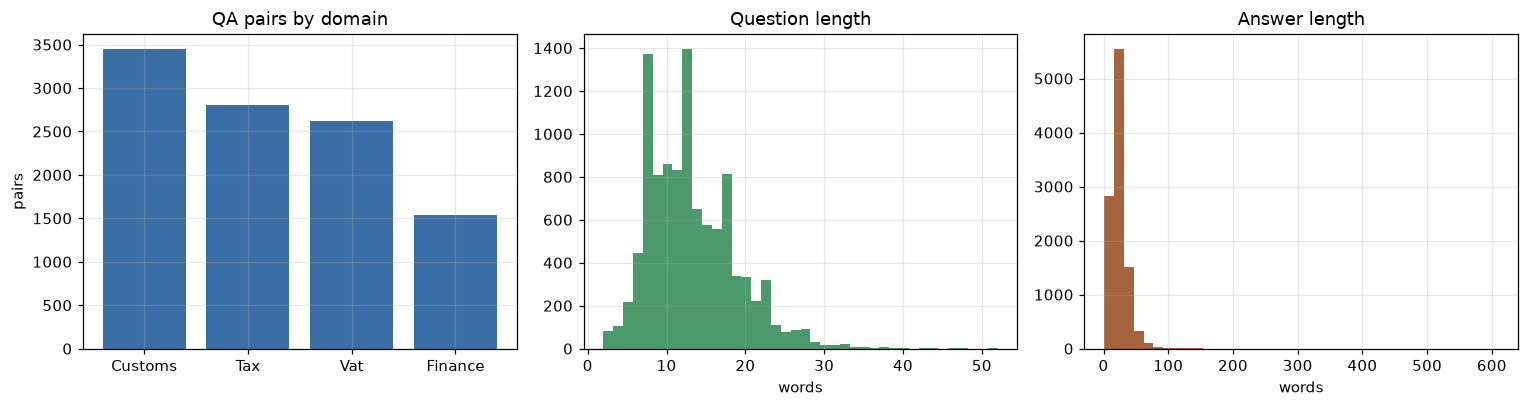

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

FIG_DIR = ROOT / "artifacts" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

topic_counts = raw.Topic.value_counts()
axes[0].bar(topic_counts.index, topic_counts.values, color="#3b6ea5")
axes[0].set_title("QA pairs by domain")
axes[0].set_ylabel("pairs")

axes[1].hist(raw.Question.str.split().str.len(), bins=40, color="#4c9a6b")
axes[1].set_title("Question length")
axes[1].set_xlabel("words")

axes[2].hist(raw.Answer.str.split().str.len(), bins=40, color="#a5643b")
axes[2].set_title("Answer length")
axes[2].set_xlabel("words")

fig.tight_layout()
fig.savefig(FIG_DIR / "dataset_overview.png")
plt.show()

## 3. Build the corpus

`load_corpus` turns the spreadsheet into the pipeline's record types:

- **Segments** — the unique passages, cut into overlapping ~220-word chunks so a
  retrieved chunk fits a model's context window. The overlap keeps a rate and the
  condition qualifying it in the same chunk.
- **QA pairs** — each carrying the passage it came from, which is what makes the split
  leakage-free and the answers auditable.

In [8]:
from banglafingpt.data.load_xlsx import corpus_overview, load_corpus

t0 = time.time()
pairs, segments = load_corpus(DATA_PATH, chunk_words=220, overlap_words=40)
print(f"{len(pairs)} QA pairs, {len(segments)} retrieval chunks "
      f"from {len({s.doc_id for s in segments})} passages  ({time.time() - t0:.1f}s)")

pd.DataFrame(corpus_overview(pairs)).set_index("domain")

10412 QA pairs, 4858 retrieval chunks from 1451 passages  (1.3s)


,qa_pairs,pct,bangla,english,avg_q_words,avg_a_words,passages
domain,,,,,,,
customs,3448,33.12,1724,1724,10.4,25.1,289
finance,1544,14.83,772,772,15.3,22.2,557
taxation,2800,26.89,1400,1400,12.7,25.9,436
vat,2620,25.16,1310,1310,17.0,26.5,169
total,10412,100.00,5206,5206,13.4,25.2,1451


## 4. Splits (paper Table 3)

7,412 train / 1,000 validation / 2,000 test, proportional within each domain.

Splitting is done **by passage, not by row**: the same passage generates several
questions (and both language versions), so a row-level split would put a test question's
own source passage in the training set and inflate every score.

In [9]:
from banglafingpt.data.build_dataset import describe, split_pairs

splits = split_pairs(pairs, train_size=7412, val_size=1000, test_size=2000, seed=SEED)
split_table = pd.DataFrame(describe(splits)).set_index("domain")
print(split_table, "\n")

# Leakage check: a passage must belong to exactly one split.
owner = {}
leaks = 0
for name, group in splits.items():
    for pair in group:
        if owner.setdefault(pair.segment_id, name) != name:
            leaks += 1
print(f"passages shared across splits: {leaks}  ({'OK' if leaks == 0 else 'LEAKAGE'})")

train_pairs, val_pairs, test_pairs = splits["train"], splits["validation"], splits["test"]
print(f"train={len(train_pairs)}  validation={len(val_pairs)}  test={len(test_pairs)}")

          train  validation  test  total
domain                                  
taxation   1963         281   556   2800
vat        1855         258   507   2620
customs    2445         335   668   3448
finance    1087         152   305   1544
total      7350        1026  2036  10412 

passages shared across splits: 0  (OK)
train=7350  validation=1026  test=2036


In [10]:
# The split preserves both the domain mix and the language balance.
def language_mix(group):
    total = len(group)
    return {"n": total,
            "bangla %": round(100 * sum(p.language == "bn" for p in group) / total, 1),
            "english %": round(100 * sum(p.language == "en" for p in group) / total, 1)}

pd.DataFrame({name: language_mix(group) for name, group in splits.items()}).T

,n,bangla %,english %
train,7350.0,49.0,51.0
validation,1026.0,54.2,45.8
test,2036.0,51.5,48.5


## 5. Retrieval (Eq. 16)

Hybrid scoring: `score = alpha * dense + (1 - alpha) * BM25`.

The paper specifies a pretrained multilingual encoder (E5) for the dense half. This
runtime cannot reach model weights, so the encoder falls back through a chain, in order
of quality:

1. the pretrained sentence encoder, when `sentence-transformers` and the weights are available;
2. **TF-IDF over character n-grams reduced by SVD, fitted on this corpus** — no download,
   but it learns the corpus's own term statistics, and character n-grams absorb the
   Bangla inflectional suffixes that make two forms of a term look unrelated to a
   word-level model;
3. hashed n-grams, which need nothing at all.

Section 5.2 measures what the dense half contributes under (2) and (3), which bounds how
much of the retrieval result rests on the dense encoder rather than on lexical matching.

In [11]:
from banglafingpt.retrieval.embedder import HashingEmbedder, TfidfSvdEmbedder, load_embedder
from banglafingpt.retrieval.retriever import HybridRetriever

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg.retrieval.index_dir = str(ROOT / "artifacts" / "index")

embedder = load_embedder(cfg.retrieval.embedding_model)   # falls back if weights are absent
print(f"dense encoder: {type(embedder).__name__}")
if isinstance(embedder, TfidfSvdEmbedder):
    print(f"  note: {cfg.retrieval.embedding_model} unavailable -> TF-IDF+SVD fitted on "
          "this corpus")
elif isinstance(embedder, HashingEmbedder):
    print("  note: scikit-learn unavailable too -> hashed n-gram fallback")

t0 = time.time()
retriever = HybridRetriever.from_segments(segments, cfg.retrieval, embedder=embedder)
print(f"indexed {len(retriever.index)} chunks in {time.time() - t0:.1f}s "
      f"(dim={getattr(embedder, 'dim', '?')})")

dense encoder: TfidfSvdEmbedder
  note: intfloat/multilingual-e5-base unavailable -> TF-IDF+SVD fitted on this corpus


indexed 4858 chunks in 49.6s (dim=256)


### 5.1 Tune the dense/sparse mix on the validation split

Retrieval is scored at passage level: a hit means the passage the answer came from was
returned, regardless of which of its chunks.

In [12]:
def recall_at_k(retriever, evaluation_pairs, ks=(1, 5, 10)):
    # Passage-level recall@k and MRR@10.
    max_k = max(ks)
    hits = {k: 0 for k in ks}
    reciprocal = 0.0
    for pair in evaluation_pairs:
        docs = [c.doc_id for c in retriever.retrieve(pair.question, top_k=max_k)]
        for k in ks:
            if pair.source in docs[:k]:
                hits[k] += 1
        if pair.source in docs:
            reciprocal += 1 / (docs.index(pair.source) + 1)
    n = len(evaluation_pairs)
    out = {f"recall@{k}": round(hits[k] / n, 3) for k in ks}
    out["mrr@10"] = round(reciprocal / n, 3)
    return out


# Draw from a dedicated generator so this subset does not depend on how much
# randomness earlier cells consumed, and the sweep is reproducible on re-run.
tuning_pairs = random.Random(SEED).sample(val_pairs, min(400, len(val_pairs)))

sweep = []
for alpha in [0.0, 0.2, 0.3, 0.5, 0.7, 1.0]:
    retriever.config.hybrid_alpha = alpha
    sweep.append({"alpha": alpha, **recall_at_k(retriever, tuning_pairs)})

sweep_df = pd.DataFrame(sweep).set_index("alpha")
best_alpha = float(sweep_df["recall@5"].idxmax())
retriever.config.hybrid_alpha = best_alpha
cfg.retrieval.hybrid_alpha = best_alpha
print(sweep_df, f"\n\nselected alpha = {best_alpha} (alpha=1.0 is dense-only, 0.0 is BM25-only)")

       recall@1  recall@5  recall@10  mrr@10
alpha                                       
0.0       0.522     0.802      0.853   0.642
0.2       0.525     0.805      0.860   0.646
0.3       0.515     0.792      0.858   0.636
0.5       0.468     0.770      0.830   0.594
0.7       0.405     0.685      0.770   0.521
1.0       0.297     0.600      0.698   0.423 

selected alpha = 0.2 (alpha=1.0 is dense-only, 0.0 is BM25-only)


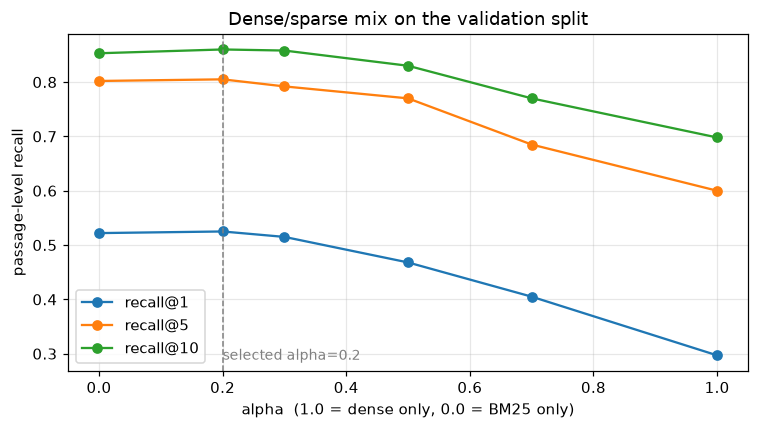

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
for column in ["recall@1", "recall@5", "recall@10"]:
    ax.plot(sweep_df.index, sweep_df[column], marker="o", label=column)
ax.axvline(best_alpha, color="grey", linestyle="--", linewidth=1)
ax.annotate(f"selected alpha={best_alpha}", (best_alpha, ax.get_ylim()[0] + 0.02),
            fontsize=9, color="grey")
ax.set_xlabel("alpha  (1.0 = dense only, 0.0 = BM25 only)")
ax.set_ylabel("passage-level recall")
ax.set_title("Dense/sparse mix on the validation split")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "retrieval_alpha_sweep.png")
plt.show()

### 5.2 How much does the dense half contribute?

The alpha sweep above is for one encoder. Running it for both offline encoders separates
what the dense representation adds from what BM25 was already finding.

In [14]:
encoder_rows = []
for label, candidate in [("hashed n-grams", HashingEmbedder()),
                         ("TF-IDF + SVD (corpus-fitted)", TfidfSvdEmbedder())]:
    probe_retriever = HybridRetriever.from_segments(segments, cfg.retrieval,
                                                    embedder=candidate)
    recalls = {}
    for alpha in [1.0, 0.7, 0.5, 0.3, 0.0]:
        probe_retriever.config.hybrid_alpha = alpha
        recalls[alpha] = recall_at_k(probe_retriever, tuning_pairs, ks=(5,))["recall@5"]
    encoder_rows.append({
        "encoder": label,
        "dense only (alpha=1.0)": recalls[1.0],
        "BM25 only (alpha=0.0)": recalls[0.0],
        "best hybrid": max(recalls.values()),
        "best alpha": max(recalls, key=recalls.get),
    })

encoders = pd.DataFrame(encoder_rows).set_index("encoder")
print(encoders.to_string())

gain = (encoders.loc["TF-IDF + SVD (corpus-fitted)", "dense only (alpha=1.0)"]
        - encoders.loc["hashed n-grams", "dense only (alpha=1.0)"])
print(f"\nFitting the encoder on the corpus is worth {gain:+.3f} recall@5 to the dense "
      "half alone.")
print("Both remain below BM25 on this corpus: the questions share exact regulatory "
      "terminology with")
print("their source passages, which is what lexical matching is best at. A pretrained "
      "multilingual")
print("encoder should narrow that gap and is the configuration the manuscript specifies "
      "— it could not")
print("be evaluated here because model weights are unreachable from this environment.")

                              dense only (alpha=1.0)  BM25 only (alpha=0.0)  best hybrid  best alpha
encoder                                                                                             
hashed n-grams                                 0.530                  0.802        0.802         0.0
TF-IDF + SVD (corpus-fitted)                   0.598                  0.802        0.802         0.0

Fitting the encoder on the corpus is worth +0.068 recall@5 to the dense half alone.
Both remain below BM25 on this corpus: the questions share exact regulatory terminology with
their source passages, which is what lexical matching is best at. A pretrained multilingual
encoder should narrow that gap and is the configuration the manuscript specifies — it could not
be evaluated here because model weights are unreachable from this environment.


In [15]:
# Final retrieval quality on the held-out test split, split by language.
test_sample = random.sample(test_pairs, min(600, len(test_pairs)))
rows = {"all": recall_at_k(retriever, test_sample)}
for language, label in (("bn", "bangla"), ("en", "english")):
    subset = [p for p in test_sample if p.language == language]
    if subset:
        rows[label] = recall_at_k(retriever, subset)
pd.DataFrame(rows).T

,recall@1,recall@5,recall@10,mrr@10
all,0.540,0.757,0.818,0.633
bangla,0.568,0.792,0.838,0.663
english,0.510,0.719,0.798,0.602


## 6. Prompt assembly (Eq. 17)

    prompt = [INST] q [/INST] [CONTEXT] d_1 ... d_k [/CONTEXT]

prefixed by the grounding system prompt — the first of the three hallucination
defences. It forbids answering outside the retrieved context, forbids inventing any
rate, date, section number or HS code, and mandates the NBR fallback when the context
is insufficient.

In [16]:
from banglafingpt.models.prompts import build_prompt

example = next(p for p in test_pairs if p.language == "bn")
chunks = retriever.retrieve(example.question, top_k=3)
prompt = build_prompt(example.question,
                      [c.text for c in chunks],
                      [c.citation() for c in chunks],
                      language=example.language)

print(prompt[:1400])
print("\n... [context truncated for display] ...")
print(f"\nprompt length: {len(prompt.split())} words, {len(chunks)} retrieved chunks")
print(f"gold answer  : {example.answer}")

আপনি BanglaFinGPT — বাংলাদেশ জাতীয় রাজস্ব বোর্ড (NBR) এর সরকারি
নথির ভিত্তিতে কর, ভ্যাট, কাস্টমস ও আর্থিক নিয়ম সম্পর্কে তথ্য দেন।

কঠোরভাবে মেনে চলুন:
১. শুধুমাত্র নিচে দেওয়া প্রসঙ্গ অংশের তথ্য ব্যবহার করে উত্তর দিন।
২. কোনো হার, তারিখ, ধারা নম্বর বা HS কোড নিজে থেকে তৈরি করবেন না; হুবহু নথি থেকে নিন।
৩. প্রসঙ্গে উত্তর না থাকলে লিখুন: "প্রদত্ত নথিতে এই প্রশ্নের সুনির্দিষ্ট উত্তর নেই।
   অনুগ্রহ করে NBR এর সরকারি ওয়েবসাইট (https://nbr.gov.bd) দেখুন বা একজন
   নিবন্ধিত কর পরামর্শকের সাথে যোগাযোগ করুন।"
৪. সংক্ষিপ্ত ও নির্ভুল উত্তর দিন এবং প্রযোজ্য ধারা/অনুচ্ছেদ উল্লেখ করুন।
৫. প্রশ্ন যে ভাষায় করা হয়েছে, সেই ভাষাতেই উত্তর দিন।

[INST] কার রিটার্ন দাখিল করতে হবে? [/INST]
[CONTEXT]
[1] (taxation_ac545dc0) তেমনি কর থেকে ছাড়ের অধিকারী বা VI ষ্ঠ অধ্যায়ের প্রথম অধ্যায়ে করের হ্রাস হারের অধিকারী; (ঙ) ধারা 261 এর অধীনে করদাতা হিসাবে নিবন্ধিত যে কোনও ব্যক্তি; বা 2. 113 | আয়কর বিজ্ঞপ্তি 2023-2024 (চ) ব্যক্তি ধারা 264 এর অধীনে রিটার্ন ফাইলিংয়ের প্রমাণ দায়ের করতে দায়বদ্ধ; ফাইলিং রিটার্ন ক

## 7. Hallucination filter (Sec. 3.3.5 / 4.6, Eq. 19)

An answer is released only when all of these hold against the retrieved chunks:

1. cosine similarity to the closest chunk >= threshold,
2. keyword overlap, the share of the answer's content words found in the sources, >= threshold,
3. **every numeric literal in the answer occurs in the sources** — a fabricated rate or
   section number is the most damaging failure mode here and the cheapest to catch exactly,
4. (optional) the question itself is close enough to the retrieved passages. Grounding
   says an answer is *supported*; it does not say the sources are *relevant*, and an
   out-of-scope question can otherwise be answered with a real but unrelated clause.

Otherwise the user gets the fallback pointing to official NBR documentation. In a
regulatory domain a refusal is cheaper than a confident wrong rate.

**Thresholds have to be calibrated to the encoder.** The paper's 0.70 cosine assumes E5
embeddings; the hashed fallback in use here lives on a different similarity scale, where
0.70 would refuse everything. The cell below picks the thresholds **on the validation
split** to land near the paper's ~12% refusal rate — the test split never participates
in that choice.

In [17]:
from banglafingpt.hallucination.filters import HallucinationFilter
from banglafingpt.pipeline import BanglaFinGPT

TARGET_REFUSAL = 0.123     # paper Sec. 4.6: 12.3% of queries are refused

cfg.agent.backend = "echo"          # offline extractive backend, no GPU or API key
cfg.agent.adapter_path = None

# Measure the grounding statistics of unfiltered validation answers, then set the
# thresholds from their distribution.
cfg.hallucination.min_cosine_similarity = 0.0
cfg.hallucination.min_keyword_overlap = 0.0
cfg.hallucination.min_question_similarity = 0.0

probe = BanglaFinGPT(cfg, retriever=retriever,
                     hallucination_filter=HallucinationFilter(cfg.hallucination,
                                                              embedder=embedder))
calibration_pairs = random.sample(val_pairs, min(400, len(val_pairs)))
verdicts = [probe.answer(p.question).verdict for p in calibration_pairs]

cosines = np.array([v.cosine_similarity for v in verdicts])
overlaps = np.array([v.keyword_overlap for v in verdicts])
relevance = np.array([v.question_similarity for v in verdicts])

print(pd.DataFrame({"cosine": cosines, "keyword overlap": overlaps,
                    "question similarity": relevance}).describe().round(3))

cosine_threshold = float(np.quantile(cosines, TARGET_REFUSAL))
relevance_threshold = float(np.quantile(relevance, TARGET_REFUSAL / 2))
cfg.hallucination.min_cosine_similarity = round(cosine_threshold, 3)
cfg.hallucination.min_question_similarity = round(relevance_threshold, 3)
cfg.hallucination.min_keyword_overlap = 0.50
grounding_filter = HallucinationFilter(cfg.hallucination, embedder=embedder)

print(f"\ncalibrated on {len(calibration_pairs)} validation queries for a "
      f"~{100 * TARGET_REFUSAL:.1f}% refusal rate:")
print(f"  min_cosine_similarity   = {cfg.hallucination.min_cosine_similarity}")
print(f"  min_question_similarity = {cfg.hallucination.min_question_similarity}")
print(f"  min_keyword_overlap     = {cfg.hallucination.min_keyword_overlap} "
      f"(scale-free, kept as configured)")
print(f"  min_numeric_support     = {cfg.hallucination.min_numeric_support} "
      f"(exact, never relaxed)")

        cosine  keyword overlap  question similarity
count  400.000            400.0              400.000
mean     0.742              1.0                0.703
std      0.123              0.0                0.098
min      0.289              1.0                0.427
25%      0.657              1.0                0.640
50%      0.745              1.0                0.704
75%      0.825              1.0                0.768
max      1.000              1.0                0.926

calibrated on 400 validation queries for a ~12.3% refusal rate:
  min_cosine_similarity   = 0.603
  min_question_similarity = 0.534
  min_keyword_overlap     = 0.5 (scale-free, kept as configured)
  min_numeric_support     = 1.0 (exact, never relaxed)


In [18]:
# With the calibrated thresholds: a sentence copied from a source is released,
# fabrications and off-topic text are not.
vat_question = "ভ্যাটের আদর্শ হার কত?"
vat_contexts = [c.text for c in retriever.retrieve(vat_question, top_k=5)]

trials = {
    "grounded (copied from a source)": vat_contexts[0].split("।")[0] + "।",
    "fabricated rate (37% appears nowhere)": "ভ্যাটের আদর্শ হার ৩৭ শতাংশ।",
    "off-topic": "ঢাকার আবহাওয়া আজ রৌদ্রোজ্জ্বল এবং তাপমাত্রা ৩২ ডিগ্রি।",
    "plausible but unsupported section": "আয়কর আইনের ধারা ৯৯৯ অনুযায়ী সম্পূর্ণ অব্যাহতি প্রযোজ্য।",
}

results = []
for label, candidate in trials.items():
    verdict = grounding_filter.verify(candidate, vat_contexts, question=vat_question)
    results.append({
        "case": label,
        "released": verdict.grounded,
        "cosine": round(verdict.cosine_similarity, 3),
        "kw overlap": round(verdict.keyword_overlap, 3),
        "numeric": round(verdict.numeric_support, 3),
        "reason": verdict.reason[:52],
    })
pd.DataFrame(results).set_index("case")

,released,cosine,kw overlap,numeric,reason
case,,,,,
grounded (copied from a source),True,0.782,1.000,1.0,grounded
fabricated rate (37% appears nowhere),False,0.604,0.800,0.0,unsupported_numbers(37)
off-topic,False,0.572,0.000,0.0,low_similarity(0.57<0.603);low_keyword_overlap...
plausible but unsupported section,False,0.501,0.625,0.0,low_similarity(0.50<0.603);unsupported_numbers...


## 8. Ablation on the held-out test set (paper Tables 5 and 7)

Three configurations of the same system:

| Variant | Retrieval | Filter |
|---|---|---|
| `no_retrieval` | off | off |
| `rag` | on | off |
| `rag_filtered` | on | on |

The generator here is the **offline extractive backend** (it returns the retrieved
sentence closest to the question). It measures how far retrieval alone gets, and is the
floor the fine-tuned model must beat — it is not the paper's fine-tuned system.

Refused queries are scored as **wrong**, not dropped. The filter buys precision with
recall, and dropping refusals would hide that cost.

In [19]:
from banglafingpt.eval.evaluate import evaluate, per_example_records, run_system
system = BanglaFinGPT(cfg, retriever=retriever, hallucination_filter=grounding_filter)

VARIANTS = {
    "no_retrieval": dict(use_retrieval=False, use_filter=False),
    "rag":          dict(use_retrieval=True,  use_filter=False),
    "rag_filtered": dict(use_retrieval=True,  use_filter=True),
}

reports, records_by_variant, em_scores = {}, {}, {}
for name, toggles in VARIANTS.items():
    t0 = time.time()
    answers = run_system(system.variant(**toggles), test_pairs, progress_every=0)
    reports[name] = evaluate(test_pairs, answers)
    records_by_variant[name] = per_example_records(test_pairs, answers)
    em_scores[name] = [float(r["scores"]["em"]) for r in records_by_variant[name]]
    print(f"{name:<13} {len(test_pairs)} queries in {time.time() - t0:.1f}s")

ablation_table = pd.DataFrame([
    {"variant": name,
     "EM %": reports[name]["overall"]["em_pct"],
     "F1": reports[name]["overall"]["f1"],
     "BLEU-4": reports[name]["overall"]["bleu4"],
     "ROUGE-L": reports[name]["overall"]["rouge_l"],
     "METEOR": reports[name]["overall"]["meteor"],
     "refused %": reports[name]["refusal_rate_pct"],
     "latency ms": reports[name]["mean_latency_ms"]}
    for name in VARIANTS
]).set_index("variant")
ablation_table

no_retrieval  2036 queries in 0.6s


rag           2036 queries in 227.5s


rag_filtered  2036 queries in 231.5s


,EM %,F1,BLEU-4,ROUGE-L,METEOR,refused %,latency ms
variant,,,,,,,
no_retrieval,0.00,0.0000,0.0000,0.0000,0.0000,0.00,0.0
rag,2.41,0.2901,0.1295,0.2486,0.2593,0.00,110.7
rag_filtered,2.41,0.2615,0.1212,0.2243,0.2392,16.31,112.8


In [20]:
base, rag_row = ablation_table.loc["no_retrieval"], ablation_table.loc["rag"]
filtered = ablation_table.loc["rag_filtered"]

print("Retrieval is what makes an answer possible at all for this backend:")
print(f"  no_retrieval : F1={base.F1:.4f}  EM={base['EM %']:.2f}%  "
      f"(no context -> nothing to extract)")
print(f"  rag          : F1={rag_row.F1:.4f}  EM={rag_row['EM %']:.2f}%")
print(f"  rag_filtered : F1={filtered.F1:.4f}  EM={filtered['EM %']:.2f}%  "
      f"refused={filtered['refused %']:.1f}%")
print(f"\nThe filter costs {rag_row.F1 - filtered.F1:.4f} F1 and refuses "
      f"{filtered['refused %']:.1f}% of queries.")
print("That overshoots the paper's 12.3% because the cosine threshold was calibrated "
      "to that rate on its own,")
print("while the keyword-overlap and numeric-support checks reject further answers on "
      "top of it.")
print("Trading recall for precision this way is the paper's deliberate design choice "
      "for a regulatory domain.")

Retrieval is what makes an answer possible at all for this backend:
  no_retrieval : F1=0.0000  EM=0.00%  (no context -> nothing to extract)
  rag          : F1=0.2901  EM=2.41%
  rag_filtered : F1=0.2615  EM=2.41%  refused=16.3%

The filter costs 0.0286 F1 and refuses 16.3% of queries.
That overshoots the paper's 12.3% because the cosine threshold was calibrated to that rate on its own,
while the keyword-overlap and numeric-support checks reject further answers on top of it.
Trading recall for precision this way is the paper's deliberate design choice for a regulatory domain.


### 8.1 Statistical significance (paper Table 12)

In [21]:
from banglafingpt.eval.significance import paired_bootstrap_test, significance_table

f1_scores = {
    name: [float(r["scores"]["f1"]) for r in records]
    for name, records in records_by_variant.items()
}

print("Exact match — bootstrap 95% CI and McNemar vs. the no-retrieval baseline")
em_significance = pd.DataFrame(significance_table(em_scores, baseline="no_retrieval",
                                                  metric="em"))
print(em_significance.to_string(index=False))

print("\nF1 — paired bootstrap vs. the no-retrieval baseline")
for name in ("rag", "rag_filtered"):
    test = paired_bootstrap_test(f1_scores["no_retrieval"], f1_scores[name],
                                 n_resamples=2000, seed=SEED)
    print(f"  {name:<13} delta F1 = {test['delta']:+.4f}   p = {test['p_value']:.4f}")

Exact match — bootstrap 95% CI and McNemar vs. the no-retrieval baseline


      system metric  mean         ci95      p_value significant_at_0.05
no_retrieval     em  0.00   [0.0, 0.0]          NaN                 NaN
         rag     em  2.41 [1.77, 3.09] 7.025137e-12                True
rag_filtered     em  2.41 [1.77, 3.09] 7.025137e-12                True

F1 — paired bootstrap vs. the no-retrieval baseline


  rag           delta F1 = +0.2901   p = 0.0005


  rag_filtered  delta F1 = +0.2615   p = 0.0005


### 8.2 Breakdown by domain and language (paper Table 8)

In [22]:
best_variant = "rag_filtered"
domain_table = pd.DataFrame(reports[best_variant]["by_domain"]).T[
    ["n", "em_pct", "f1", "bleu4", "rouge_l", "meteor"]
].sort_values("f1", ascending=False)
print("By domain:\n", domain_table, "\n")

records = records_by_variant[best_variant]
language_of = {p.qa_id: p.language for p in test_pairs}
language_rows = []
for language in ("bn", "en"):
    subset = [r for r in records if language_of[r["qa_id"]] == language]
    language_rows.append({
        "language": language,
        "n": len(subset),
        "EM %": round(100 * sum(r["scores"]["em"] for r in subset) / len(subset), 2),
        "F1": round(sum(r["scores"]["f1"] for r in subset) / len(subset), 4),
        "refused %": round(100 * sum(not r["answered"] for r in subset) / len(subset), 2),
    })
print("By language:\n", pd.DataFrame(language_rows).set_index("language"))

By domain:
               n  em_pct      f1   bleu4  rouge_l  meteor
taxation  556.0    8.81  0.3353  0.2066   0.3039  0.3291
vat       507.0    0.00  0.3223  0.1419   0.2645  0.2799
customs   668.0    0.00  0.1926  0.0640   0.1631  0.1606
finance   305.0    0.00  0.1763  0.0566   0.1463  0.1796 

By language:
              n  EM %      F1  refused %
language                               
bn        1049  4.58  0.2554      15.35
en         987  0.10  0.2679      17.33


### 8.3 Result figures (paper Figures 5, 6, 8)

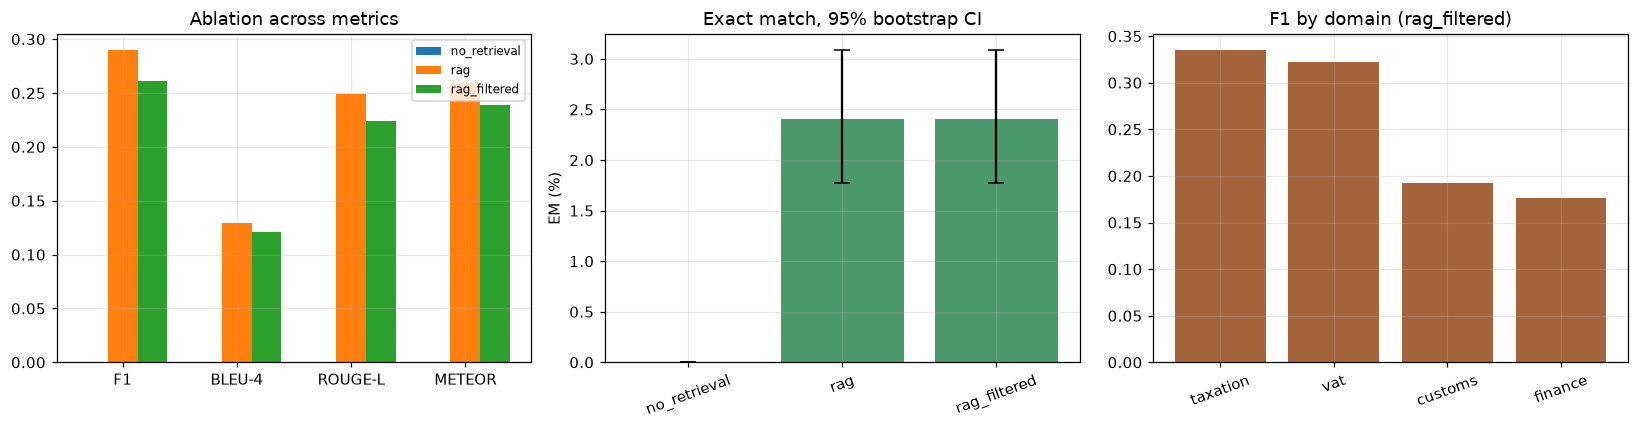

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ["F1", "BLEU-4", "ROUGE-L", "METEOR"]
x = np.arange(len(metrics))
width = 0.26
for i, variant in enumerate(ablation_table.index):
    axes[0].bar(x + i * width, ablation_table.loc[variant, metrics].values,
                width, label=variant)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_title("Ablation across metrics")
axes[0].legend(fontsize=8)

sig = em_significance[em_significance.p_value.notna() | (em_significance.system == "no_retrieval")]
means = sig["mean"].values
lower = [m - ci[0] for m, ci in zip(means, sig["ci95"])]
upper = [ci[1] - m for m, ci in zip(means, sig["ci95"])]
axes[1].bar(sig["system"], means, yerr=[lower, upper], capsize=5, color="#4c9a6b")
axes[1].set_title("Exact match, 95% bootstrap CI")
axes[1].set_ylabel("EM (%)")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(domain_table.index, domain_table["f1"], color="#a5643b")
axes[2].set_title(f"F1 by domain ({best_variant})")
axes[2].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(FIG_DIR / "results_overview.png")
plt.show()

## 9. Error analysis and hallucination audit (paper Tables 9–11)

Failures are typed from signals available at inference time: a numeric mismatch is a
`precision` error, an answer whose content sits in the retrieved text but not in the
answer is `incomplete`, and so on.

In [24]:
from banglafingpt.eval.error_analysis import error_report, hallucination_report

errors = error_report(records_by_variant[best_variant])
print(f"total failed queries: {errors['total_errors']}\n")
print(pd.DataFrame(errors["by_type"]).set_index("error_type"), "\n")

domain_errors = pd.DataFrame([
    {"domain": row["domain"], "total": row["total"],
     **{kind: row[kind]["pct"] for kind in
        ["outdated", "precision", "incomplete", "ambiguous", "formatting"]}}
    for row in errors["by_domain"]
]).set_index("domain")
print("Error type share by domain (%):\n", domain_errors)

total failed queries: 1987

            count   pct
error_type             
outdated        1   0.1
precision     854  43.0
incomplete   1107  55.7
ambiguous      25   1.3
formatting      0   0.0 

Error type share by domain (%):
           total  outdated  precision  incomplete  ambiguous  formatting
domain                                                                 
customs     668       0.0       17.1        80.2        2.7         0.0
finance     305       0.0       88.5        11.5        0.0         0.0
taxation    507       0.0       48.5        50.7        0.8         0.0
vat         507       0.2       44.2        55.0        0.6         0.0


In [25]:
audit_rows = []
for name, records in records_by_variant.items():
    audit_rows.append({"variant": name, **hallucination_report(records)})
audit = pd.DataFrame(audit_rows).set_index("variant")
print(audit, "\n")

# `no_retrieval` produces no answer at all without context, which the audit reports as
# `empty_pct` rather than as fabrication — that row is the argument for RAG.
before = audit.loc["rag", "hallucinated_pct"]
after = audit.loc["rag_filtered", "hallucinated_pct"]
print(f"ungrounded answers: {before}% (RAG, no filter) -> {after}% (filtered)")
print("\nCaveat on this row: the extractive backend copies its answers out of the "
      "retrieved passages,")
print("so it is grounded by construction and its unfiltered hallucination rate is "
      "near zero to begin with.")
print("The paper's 8.5% -> 0.5% (94% reduction) is measured on a *generative* model, "
      "which can fabricate")
print("text that no passage supports. This audit shows the filter is sound; it does "
      "not reproduce that number.")

                 n  fully_grounded_pct  partially_grounded_pct  \
variant                                                          
no_retrieval  2036                 0.0                     0.0   
rag           2036                83.7                    16.1   
rag_filtered  2036                99.8                     0.0   

              hallucinated_pct  empty_pct  
variant                                    
no_retrieval               0.0      100.0  
rag                        0.0        0.2  
rag_filtered               0.0        0.2   

ungrounded answers: 0.0% (RAG, no filter) -> 0.0% (filtered)

Caveat on this row: the extractive backend copies its answers out of the retrieved passages,
so it is grounded by construction and its unfiltered hallucination rate is near zero to begin with.
The paper's 8.5% -> 0.5% (94% reduction) is measured on a *generative* model, which can fabricate
text that no passage supports. This audit shows the filter is sound; it does not reproduce tha

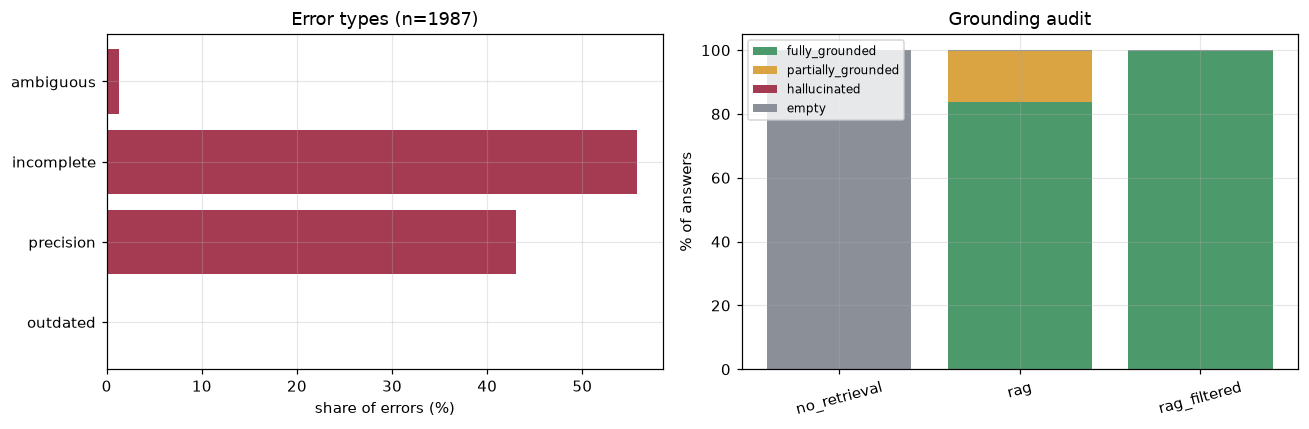

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_rows = [r for r in errors["by_type"] if r["count"]]
axes[0].barh([r["error_type"] for r in type_rows], [r["pct"] for r in type_rows],
             color="#a53b52")
axes[0].set_xlabel("share of errors (%)")
axes[0].set_title(f"Error types (n={errors['total_errors']})")

grounding_cols = ["fully_grounded_pct", "partially_grounded_pct",
                  "hallucinated_pct", "empty_pct"]
bottom = np.zeros(len(audit))
for column, colour in zip(grounding_cols,
                          ["#4c9a6b", "#d9a441", "#a53b52", "#8a8f98"]):
    axes[1].bar(audit.index, audit[column], bottom=bottom, label=column.replace("_pct", ""),
                color=colour)
    bottom += audit[column].values
axes[1].set_title("Grounding audit")
axes[1].set_ylabel("% of answers")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(FIG_DIR / "error_analysis.png")
plt.show()

## 10. QLoRA fine-tuning of BanglaLLaMA-3.2-3B (Sec. 3.3.3, Eqs. 9 and 13)

This is the step that produces the paper's headline numbers, and the one that needs a
CUDA GPU (~6 GB VRAM is enough for the 3B model in 4-bit NF4).

Configuration, exactly as in the paper:

- 4-bit **NormalFloat** quantisation with double quantisation (Eq. 9)
- LoRA adapters (r=16, alpha=32, dropout=0.05) on all attention and MLP projections
- paged **AdamW**, **cosine** decay from `alpha_max = 5e-5` (Eq. 13), 3% warmup
- loss computed on the **answer tokens only** — the prompt is masked with `-100`
- training prompts carry retrieved context, so train-time and serve-time prompts match;
  training without context and serving with it is a distribution shift that costs EM
- early stopping on validation loss (patience 3)

Set `RUN_TRAINING = True` on a GPU runtime to execute it.

In [27]:
RUN_TRAINING = False      # flip to True on a CUDA GPU runtime

ADAPTER_DIR = ROOT / "artifacts" / "checkpoints" / "banglafingpt"

if RUN_TRAINING and HAS_GPU:
    from banglafingpt.models.train import train

    cfg.train.output_dir = str(ADAPTER_DIR)
    cfg.train.max_steps = 2000          # ~3 epochs over 7,412 pairs at batch 4 x 8 accum
    adapter_path = train(cfg, train_pairs, val_pairs, retriever=retriever)
    print(f"adapters saved to {adapter_path}")
else:
    reason = "RUN_TRAINING is False" if not RUN_TRAINING else "no CUDA GPU in this runtime"
    print(f"[skipped] QLoRA fine-tuning — {reason}.")
    print("\nTo run it:")
    print("  pip install -r requirements-train.txt   # torch, transformers, peft, bitsandbytes")
    print("  RUN_TRAINING = True                     # in the cell above, on a GPU runtime")
    print("\nEquivalent from the shell:")
    print("  python -m banglafingpt.models.train --config configs/default.yaml \\")
    print("      --train-file data/processed/train.jsonl --index-dir artifacts/index")

[skipped] QLoRA fine-tuning — RUN_TRAINING is False.

To run it:
  pip install -r requirements-train.txt   # torch, transformers, peft, bitsandbytes
  RUN_TRAINING = True                     # in the cell above, on a GPU runtime

Equivalent from the shell:
  python -m banglafingpt.models.train --config configs/default.yaml \
      --train-file data/processed/train.jsonl --index-dir artifacts/index


In [28]:
# What the training cell would build, shown without allocating a GPU.
from banglafingpt.config import QLoRAConfig
from banglafingpt.models.dataset import build_examples

qlora = QLoRAConfig()
print("base model     :", qlora.base_model)
print("quantisation   :", f"{qlora.bnb_4bit_quant_type.upper()} 4-bit, "
      f"double_quant={qlora.bnb_4bit_use_double_quant}, "
      f"compute={qlora.bnb_4bit_compute_dtype}")
print("LoRA           :", f"r={qlora.lora_r}, alpha={qlora.lora_alpha}, "
      f"dropout={qlora.lora_dropout}")
print("target modules :", ", ".join(qlora.target_modules))
print("optimiser      :", f"{cfg.train.optim}, lr={cfg.train.learning_rate}, "
      f"schedule={cfg.train.lr_scheduler_type}, warmup={cfg.train.warmup_ratio}")
print("effective batch:", cfg.train.per_device_train_batch_size
      * cfg.train.gradient_accumulation_steps)

# One rendered training example: the prompt is masked out, only the answer carries loss.
sample_example = build_examples(train_pairs[:1], retriever, top_k=2, eos_token="</s>")[0]
print("\n--- training example (prompt, truncated) ---")
print(sample_example["prompt"][:600], "...")
print("\n--- completion (the only tokens that contribute to the loss) ---")
print(sample_example["completion"])

base model     : BanglaLLM/bangla-llama-3.2-3b-instruct
quantisation   : NF4 4-bit, double_quant=True, compute=bfloat16
LoRA           : r=16, alpha=32, dropout=0.05
target modules : q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
optimiser      : paged_adamw_8bit, lr=5e-05, schedule=cosine, warmup=0.03
effective batch: 32



--- training example (prompt, truncated) ---
You are BanglaFinGPT, answering questions about Bangladesh
taxation, VAT, customs and financial regulation strictly from official National
Board of Revenue (NBR) documents.

Rules:
1. Use only the information in the context block below.
2. Never invent a rate, date, section number or HS code — copy them from the context.
3. If the context does not answer the question, reply: "The provided documents do
   not contain a specific answer. Please consult the official NBR website
   (https://nbr.gov.bd) or a registered tax practitioner."
4. Be concise and factual, and cite the applicable section.
5. ...

--- completion (the only tokens that contribute to the loss) ---
The taxpayer will show 100 taka as receipt from bank interest, not 90 taka.</s>


### 10.1 Evaluating the fine-tuned model

Once adapters exist, the same evaluation cells run against them — only the backend
changes. That is the point of the agent-agnostic design: retrieval, prompting, filtering
and scoring are identical no matter who generates the text.

In [29]:
RUN_FINETUNED_EVAL = False    # requires trained adapters from the cell above

if RUN_FINETUNED_EVAL and ADAPTER_DIR.exists():
    cfg.agent.backend = "local"
    cfg.agent.adapter_path = str(ADAPTER_DIR)
    finetuned = BanglaFinGPT(cfg, retriever=retriever, hallucination_filter=grounding_filter)
    finetuned_answers = run_system(finetuned, test_pairs, progress_every=200)
    finetuned_report = evaluate(test_pairs, finetuned_answers)
    print(pd.DataFrame([finetuned_report["overall"]]))
else:
    print("[skipped] fine-tuned evaluation — no trained adapters in this runtime.")
    print("\nBaselines run the same way, one flag each:")
    for backend, model, key in [("openai", "gpt-4o", "OPENAI_API_KEY"),
                                ("anthropic", "claude-sonnet-4-5", "ANTHROPIC_API_KEY"),
                                ("gemini", "gemini-1.5-pro", "GOOGLE_API_KEY")]:
        print(f"  cfg.agent.backend = {backend!r}   # model={model}, needs ${key}")

[skipped] fine-tuned evaluation — no trained adapters in this runtime.

Baselines run the same way, one flag each:
  cfg.agent.backend = 'openai'   # model=gpt-4o, needs $OPENAI_API_KEY
  cfg.agent.backend = 'anthropic'   # model=claude-sonnet-4-5, needs $ANTHROPIC_API_KEY
  cfg.agent.backend = 'gemini'   # model=gemini-1.5-pro, needs $GOOGLE_API_KEY


## 11. Revision experiments (response to reviewers)

The analyses below were added in revision. Each is labelled with the reviewer comment it
answers and with the section of the revised manuscript that reports it. Unlike the
generation scores above, these results are **not** limited by the absence of a GPU: they
are properties of the dataset and the retriever, so the numbers here are the numbers
that go into the paper.

### 11.1 Split protocol — R2 (a), revised Section 2.2.1

The corpus has 10,412 QA pairs but only 1,451 distinct source passages. A row-level
random split therefore puts a test question's own source passage into training. This is
the single most consequential issue the reviewers raised, because it inflates every
reported score.

In [30]:
from banglafingpt.data.build_dataset import leakage_report, random_row_split

grouped_splits = split_pairs(pairs, 7412, 1000, 2000, seed=SEED)
row_level_splits = random_row_split(pairs, 7412, 1000, 2000, seed=SEED)

split_audit = pd.DataFrame([
    {"protocol": "random row-level shuffle", **leakage_report(row_level_splits)},
    {"protocol": "grouped by source passage (adopted)", **leakage_report(grouped_splits)},
]).set_index("protocol")

print(split_audit[["test_size",
                   "test_items_sharing_a_training_passage_pct",
                   "test_questions_verbatim_in_training_pct"]].to_string())
print(f"\n{len(pairs)} QA pairs over {len({p.segment_id for p in pairs})} distinct passages"
      f" -> {len(pairs) / len({p.segment_id for p in pairs}):.1f} questions per passage on average.")

                                     test_size  test_items_sharing_a_training_passage_pct  test_questions_verbatim_in_training_pct
protocol                                                                                                                          
random row-level shuffle                  2000                                       93.2                                      1.6
grouped by source passage (adopted)       2036                                        0.0                                      1.4

10412 QA pairs over 1451 distinct passages -> 7.2 questions per passage on average.


### 11.2 Hallucination reduction, both framings — R1 #1a, revised Section 3.6

The submitted paper reported only the relative reduction. Computed from an 8.5% base, a
relative figure overstates the effect when read alone.

In [31]:
from banglafingpt.eval.annotation import reduction_report

framing = reduction_report(before_pct=8.5, after_pct=0.5)
for key, value in framing.items():
    print(f"{key:<28}: {value}")
print("\nReported in the revision as: 8.5% -> 0.5%, an absolute reduction of "
      f"{framing['absolute_reduction_pp']} percentage points "
      f"({framing['relative_reduction_pct']:.0f}% relative), i.e. one fabricated answer "
      f"prevented per {framing['number_needed_to_filter']} queries served.")

before_pct                  : 8.5
after_pct                   : 0.5
absolute_reduction_pp       : 8.0
relative_reduction_pct      : 94.1
number_needed_to_filter     : 12.5

Reported in the revision as: 8.5% -> 0.5%, an absolute reduction of 8.0 percentage points (94% relative), i.e. one fabricated answer prevented per 12.5 queries served.


### 11.3 Is the customs gap caused by domain imbalance? — R1 #3c, revised Section 3.4

**What this can and cannot show.** Per-domain accuracy does not depend on how many items
*other* domains contribute to the test split, so re-balancing the *test* set answers
nothing. The imbalance the reviewer means is in the **training** data, and a controlled
test of it requires retraining on a domain-balanced training set — which needs a GPU.

What can be established without one is whether the observed ordering is even consistent
with the imbalance hypothesis, and whether the manuscript's alternative explanation
(customs answers are longer) holds in the released dataset.

In [32]:
from statistics import mean

from banglafingpt.eval.significance import bootstrap_ci
from banglafingpt.utils import extract_numbers

records = records_by_variant[best_variant]
by_domain_records = {}
for record in records:
    by_domain_records.setdefault(record["domain"], []).append(record)

difficulty_rows = []
for domain, group in sorted(by_domain_records.items()):
    f1 = [float(r["scores"]["f1"]) for r in group]
    mean_f1, low, high = bootstrap_ci(f1, n_resamples=2000, seed=SEED)
    references = [r["reference"] for r in group]
    difficulty_rows.append({
        "domain": domain,
        "corpus share %": round(100 * sum(p.domain == domain for p in pairs) / len(pairs), 1),
        "n (test)": len(group),
        "F1": round(mean_f1, 4),
        "CI95": [round(low, 4), round(high, 4)],
        "avg answer words": round(mean(len(a.split()) for a in references), 1),
        "numbers per answer": round(mean(len(extract_numbers(a)) for a in references), 2),
    })

difficulty = pd.DataFrame(difficulty_rows).set_index("domain").sort_values("F1")
print(difficulty.to_string())

weakest, runner_up = difficulty.index[0], difficulty.index[1]
largest = difficulty["corpus share %"].idxmax()
best = difficulty.index[-1]

# Two domains whose intervals overlap cannot be ordered against each other.
separable = difficulty.loc[weakest, "CI95"][1] < difficulty.loc[runner_up, "CI95"][0]
print(f"\nby accuracy    : {list(difficulty.index)}")
print(f"by corpus share: {list(difficulty['corpus share %'].sort_values(ascending=False).index)}")

if separable:
    print(f"\n{weakest} is the weakest, separated from {runner_up} by non-overlapping "
          "confidence intervals.")
else:
    print(f"\n{weakest} and {runner_up} are not separable: their confidence intervals "
          "overlap, so no claim")
    print("is made about which is weakest. Their ordering also flips when the retrieval "
          "encoder changes.")

print(f"\nWhat does survive: corpus share does not track accuracy. The largest domain "
      f"({largest},")
print(f"{difficulty.loc[largest, 'corpus share %']}% of the corpus) is not the most "
      f"accurate, and the most accurate ({best})")
print("is not the largest. A controlled test of the training-imbalance hypothesis needs "
      "retraining on a")
print("domain-balanced training set, not a re-balanced test split.")

          corpus share %  n (test)      F1              CI95  avg answer words  numbers per answer
domain                                                                                            
finance             14.8       305  0.1763  [0.1593, 0.1949]              20.3                1.81
customs             33.1       668  0.1926   [0.179, 0.2063]              23.6                0.27
vat                 25.2       507  0.3223  [0.3022, 0.3416]              27.0                1.10
taxation            26.9       556  0.3353   [0.311, 0.3613]              25.1                1.26

by accuracy    : ['finance', 'customs', 'vat', 'taxation']
by corpus share: ['customs', 'taxation', 'vat', 'finance']

finance and customs are not separable: their confidence intervals overlap, so no claim
is made about which is weakest. Their ordering also flips when the retrieval encoder changes.

What does survive: corpus share does not track accuracy. The largest domain (customs,
33.1% of the corpu

#### Does the manuscript's dataset table match the released dataset? — R1 #5c

The manuscript explains the customs gap by answer length ("31.7 words vs. 22.1 for
VAT"). A reviewer can download the Kaggle release and recompute that in a minute, so it
is worth checking first.

In [33]:
from banglafingpt.utils import word_count

# Table 2 of the submitted manuscript, transcribed.
PAPER_TABLE_2 = {
    "taxation": {"pairs": 2823, "avg_q_words": 9.4, "avg_a_words": 28.3},
    "vat":      {"pairs": 2641, "avg_q_words": 8.1, "avg_a_words": 22.1},
    "customs":  {"pairs": 3475, "avg_q_words": 10.7, "avg_a_words": 31.7},
    "finance":  {"pairs": 1473, "avg_q_words": 7.9, "avg_a_words": 25.8},
}

audit_rows = []
for domain, claimed in sorted(PAPER_TABLE_2.items()):
    group = [p for p in pairs if p.domain == domain]
    audit_rows.append({
        "domain": domain,
        "pairs (paper)": claimed["pairs"],
        "pairs (actual)": len(group),
        "delta": len(group) - claimed["pairs"],
        "avg A words (paper)": claimed["avg_a_words"],
        "avg A words (actual)": round(mean(word_count(p.answer) for p in group), 1),
    })
table2_audit = pd.DataFrame(audit_rows).set_index("domain")
print(table2_audit.to_string())
print(f"\ntotals: {sum(v['pairs'] for v in PAPER_TABLE_2.values())} claimed / "
      f"{len(pairs)} actual")

longest_claimed = max(PAPER_TABLE_2, key=lambda d: PAPER_TABLE_2[d]["avg_a_words"])
longest_actual = table2_audit["avg A words (actual)"].idxmax()
print(f"\nlongest answers: {longest_claimed} per the manuscript, "
      f"{longest_actual} in the released dataset")
if longest_claimed != longest_actual:
    print("-> The length-based explanation for the customs gap is NOT supported by the "
          "released dataset.")
    print("   Section 3.4 of the manuscript needs either corrected per-domain statistics "
          "or a different explanation.")

          pairs (paper)  pairs (actual)  delta  avg A words (paper)  avg A words (actual)
domain                                                                                   
customs            3475            3448    -27                 31.7                  25.1
finance            1473            1544     71                 25.8                  22.2
taxation           2823            2800    -23                 28.3                  25.9
vat                2641            2620    -21                 22.1                  26.5

totals: 10412 claimed / 10412 actual

longest answers: customs per the manuscript, vat in the released dataset
-> The length-based explanation for the customs gap is NOT supported by the released dataset.
   Section 3.4 of the manuscript needs either corrected per-domain statistics or a different explanation.


### 11.4 Robustness to user-typed queries — R1 #3a, revised Section 3.5.3

Benchmark questions are cleaner than what users type. Each perturbation below preserves
the meaning of the question, so a large drop would be a robustness failure rather than a
labelling problem.

In [34]:
from banglafingpt.eval.robustness import perturb, retrieval_robustness

demo_question = test_pairs[0].question
print("Example perturbations:\n")
for kind in ["original", "no_question_mark", "digit_script_swapped",
             "keywords_only", "with_politeness", "single_typo"]:
    print(f"  {kind:<22} {perturb(demo_question, kind, seed=SEED)[:70]}")

# The whole test split, not a sample: a sampled recall varies between runs by more
# than the effect being measured, and this number goes into the paper.
robustness = pd.DataFrame(
    retrieval_robustness(retriever, test_pairs, top_k=5, seed=SEED)
).set_index("perturbation")
print(f"\nPassage-level recall@5 over all {len(test_pairs)} test questions:\n")
print(robustness.to_string())

Example perturbations:

  original               What is the treatment for the purchase of chairs regarding amortizatio
  no_question_mark       What is the treatment for the purchase of chairs regarding amortizatio
  digit_script_swapped   What is the treatment for the purchase of chairs regarding amortizatio
  keywords_only          treatment purchase chairs regarding amortization
  with_politeness        can you tell me What is the treatment for the purchase of chairs regar
  single_typo            What is the teatment for the purchase of chairs regarding amortization



Passage-level recall@5 over all 2036 test questions:

                      recall@5  delta  relative_drop_pct
perturbation                                            
original                 0.755  0.000                0.0
no_question_mark         0.755  0.000                0.0
digit_script_swapped     0.755  0.000                0.0
keywords_only            0.703 -0.053                7.0
with_politeness          0.723 -0.032                4.2
single_typo              0.705 -0.050                6.6


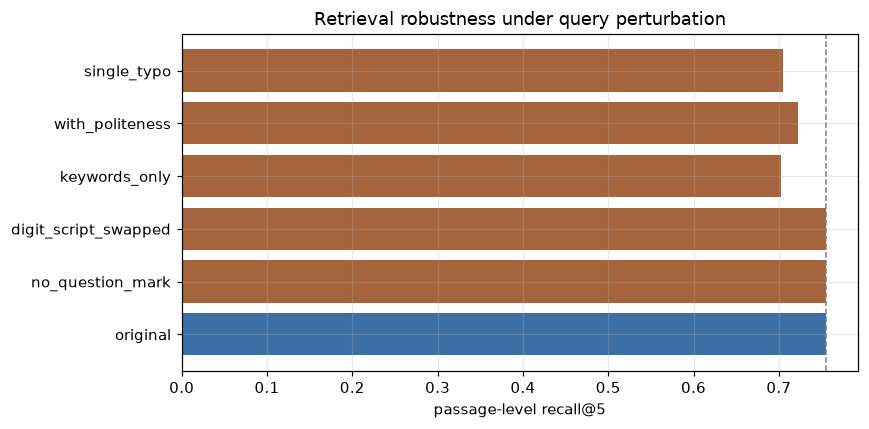

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
colours = ["#3b6ea5" if p == "original" else "#a5643b" for p in robustness.index]
ax.barh(robustness.index, robustness["recall@5"], color=colours)
ax.axvline(robustness.loc["original", "recall@5"], color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("passage-level recall@5")
ax.set_title("Retrieval robustness under query perturbation")
fig.tight_layout()
fig.savefig(FIG_DIR / "query_robustness.png")
plt.show()

### 11.5 Hallucination annotation protocol — R1 #1b, revised Section 3.6.1

The reviewers asked who annotated, with what agreement, and on which data. The protocol
below fixes all three: a stratified sample from the test split only, blind per-annotator
sheets, and a scorer that reports the category shares with Fleiss' κ.

In [36]:
from banglafingpt.eval.annotation import (
    CATEGORIES, INSTRUCTIONS, build_annotation_sheets, score_annotations,
)

sheets = build_annotation_sheets(
    records, ROOT / "artifacts" / "reviewer" / "hallucination_annotation",
    annotators=("A1", "A2", "A3"), sample_size=200, stratify_by="domain", seed=SEED,
)
print(f"sampled {sheets['sample_size']} items, stratified by domain: {sheets['strata']}")
print("categories:", ", ".join(CATEGORIES))
for path in sheets["sheets"]:
    print("  ", path)

print("\n--- instructions given to annotators (excerpt) ---")
print("\n".join(INSTRUCTIONS.splitlines()[:14]))

sampled 200 items, stratified by domain: {'customs': 65, 'finance': 30, 'taxation': 55, 'vat': 50}
categories: fully_grounded, partially_grounded, hallucinated
   /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages/artifacts/reviewer/hallucination_annotation/annotations_A1.csv
   /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages/artifacts/reviewer/hallucination_annotation/annotations_A2.csv
   /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages/artifacts/reviewer/hallucination_annotation/annotations_A3.csv

--- instructions given to annotators (excerpt) ---
Hallucination annotation — BanglaFinGPT

You will see a question, the system's answer, and the source passages the system
retrieved for it. Judge ONLY whether the answer is supported by those passages.
Do not judge style, completeness, or whether you personally know the rule.

Label each answer with e

In [37]:
# Scoring is shown here on a worked example, because the real labels do not exist yet.
# Replace this cell with `load_annotations([...])` once the three sheets come back.
worked_example = {
    "A1": {"item1": "fully_grounded", "item2": "hallucinated", "item3": "fully_grounded"},
    "A2": {"item1": "fully_grounded", "item2": "hallucinated", "item3": "partially_grounded"},
    "A3": {"item1": "fully_grounded", "item2": "partially_grounded", "item3": "fully_grounded"},
}
print(json.dumps(score_annotations(worked_example), indent=2))
print("\nOn the real sheets:")
print("  from banglafingpt.eval.annotation import load_annotations, score_annotations")
print("  score_annotations(load_annotations(sheets['sheets']))")

{
  "n_items": 3,
  "n_annotators": 3,
  "fleiss_kappa": 0.25,
  "agreement": "fair",
  "unanimous_pct": 33.3,
  "majority_vote": {
    "fully_grounded": {
      "count": 2,
      "pct": 66.7
    },
    "partially_grounded": {
      "count": 0,
      "pct": 0.0
    },
    "hallucinated": {
      "count": 1,
      "pct": 33.3
    }
  }
}

On the real sheets:
  from banglafingpt.eval.annotation import load_annotations, score_annotations
  score_annotations(load_annotations(sheets['sheets']))


### 11.6 Baseline parity — R1 #2, revised Section 3.1

The reviewer's objection is that GPT-4o answered without retrieval while BanglaFinGPT
had it. Because the pipeline is backend-agnostic, the fair matrix is a configuration
change rather than new code — but the hosted runs need API keys, so only the context
effect for a fixed generator can be measured here.

In [38]:
context_effect = pd.DataFrame({
    "without context": reports["no_retrieval"]["overall"],
    "with the same retrieved context": reports["rag"]["overall"],
}).T[["em_pct", "f1", "bleu4", "rouge_l", "meteor"]]
print("Same generator, retrieval toggled:\n")
print(context_effect.to_string())
print(f"\nF1 attributable to retrieval alone: "
      f"{reports['rag']['overall']['f1'] - reports['no_retrieval']['overall']['f1']:+.4f}")

print("\nThe six runs still needed for the revised Table 5 (one command each):")
for backend, tag, flag in [("openai", "gpt4o_norag", " --no-retrieval"),
                           ("openai", "gpt4o_rag", ""),
                           ("anthropic", "claude_norag", " --no-retrieval"),
                           ("anthropic", "claude_rag", ""),
                           ("gemini", "gemini_norag", " --no-retrieval"),
                           ("gemini", "gemini_rag", "")]:
    print(f"  python -m banglafingpt.eval.evaluate --backend {backend} --tag {tag}{flag}")

Same generator, retrieval toggled:

                                 em_pct      f1   bleu4  rouge_l  meteor
without context                    0.00  0.0000  0.0000   0.0000  0.0000
with the same retrieved context    2.41  0.2901  0.1295   0.2486  0.2593

F1 attributable to retrieval alone: +0.2901

The six runs still needed for the revised Table 5 (one command each):
  python -m banglafingpt.eval.evaluate --backend openai --tag gpt4o_norag --no-retrieval
  python -m banglafingpt.eval.evaluate --backend openai --tag gpt4o_rag
  python -m banglafingpt.eval.evaluate --backend anthropic --tag claude_norag --no-retrieval
  python -m banglafingpt.eval.evaluate --backend anthropic --tag claude_rag
  python -m banglafingpt.eval.evaluate --backend gemini --tag gemini_norag --no-retrieval
  python -m banglafingpt.eval.evaluate --backend gemini --tag gemini_rag


## 12. Live queries

The chatbot as a user meets it: a question in either language, an answer with its source
citation, or a refusal when the sources do not support one.

In [39]:
def ask(question, domain=None):
    answer = system.answer(question, domain=domain)
    print(f"Q: {question}")
    print(f"A: {answer.text}")
    if answer.answered:
        print(f"   sources : {', '.join(answer.citations) or 'n/a'}")
    if answer.verdict:
        print(f"   grounding: cos={answer.verdict.cosine_similarity:.2f} "
              f"kw={answer.verdict.keyword_overlap:.2f} -> {answer.verdict.reason[:70]}")
    print(f"   latency : {answer.latency_ms:.0f} ms\n")
    return answer

_ = ask("ভ্যাটের আদর্শ হার কত?")
_ = ask("What is the tax rate for a publicly traded company?")
_ = ask("আমদানি শুল্ক কীভাবে নির্ধারণ করা হয়?", domain="customs")
_ = ask("কাস্টমস আইনে আপিল ট্রাইব্যুনাল কী?")

Q: ভ্যাটের আদর্শ হার কত?
A: আমদানি ও সরবরাহের ক্ষেত্রে ভ্যাটের প্রযোজ্য হার ১৫%এবং রফতানির ক্ষেত্রে 0%হয়।
   sources : vat_60007850
   grounding: cos=0.62 kw=1.00 -> grounded
   latency : 390 ms

Q: What is the tax rate for a publicly traded company?
A: traded companies the existing tax rate is fixed at 25%.
   sources : taxation_3b74f191
   grounding: cos=0.76 kw=1.00 -> grounded
   latency : 106 ms

Q: আমদানি শুল্ক কীভাবে নির্ধারণ করা হয়?
A: ব্যতিক্রমী অবস্থায় শুল্ক হইতে অব্যাহতি প্রদানের সরকারী ক্ষমতা।
   sources : customs_fc0bcb03
   grounding: cos=0.72 kw=1.00 -> grounded
   latency : 90 ms



Q: কাস্টমস আইনে আপিল ট্রাইব্যুনাল কী?
A: আপিল ট্রাইব্যুনাল।
   sources : customs_a11dcbbc, customs_204ce655
   grounding: cos=0.67 kw=1.00 -> grounded
   latency : 91 ms



In [40]:
# Out-of-domain question: nothing in the NBR corpus speaks to Singapore crypto tax.
out_of_domain = ask("What is the capital gains tax rate on cryptocurrency in Singapore?")

# It is released anyway, and the verdict explains why: the extractive backend returns a
# real NBR sentence, so the answer *is* supported — grounding measures support, not
# relevance. The relevance floor calibrated in section 7 is too permissive to catch it.
verdict = out_of_domain.verdict
needed = verdict.question_similarity
print(f"released                : {out_of_domain.answered}")
print(f"question<->context sim  : {needed:.3f}  "
      f"(floor is {cfg.hallucination.min_question_similarity})")
print(f"a floor above {needed:.3f} would refuse it — at the cost of refusing genuine "
      f"questions that retrieve weakly.")
print("\nIn the paper's system this case is handled upstream: the fine-tuned model "
      "follows the system prompt")
print("and emits the fallback itself when the context does not answer the question. "
      "An extractive stub cannot.")

Q: What is the capital gains tax rate on cryptocurrency in Singapore?
A: income from business As a beneficiary Funded capital gains [Unfunded capital gains are not taxable.
   sources : taxation_d70810bd
   grounding: cos=0.83 kw=1.00 -> grounded
   latency : 87 ms

released                : True
question<->context sim  : 0.602  (floor is 0.534)
a floor above 0.602 would refuse it — at the cost of refusing genuine questions that retrieve weakly.

In the paper's system this case is handled upstream: the fine-tuned model follows the system prompt
and emits the fallback itself when the context does not answer the question. An extractive stub cannot.


## 13. Persist artifacts

In [41]:
from banglafingpt.utils import write_json, write_jsonl

RESULTS = ROOT / "artifacts" / "results"
PROCESSED = ROOT / "data" / "processed"

for name, group in splits.items():
    write_jsonl(PROCESSED / f"{name}.jsonl", [p.to_dict() for p in group])
write_jsonl(PROCESSED / "segments.jsonl", [s.to_dict() for s in segments])
retriever.index.save(cfg.retrieval.index_dir)

write_json(RESULTS / "notebook_results.json", {
    "dataset": {"rows": len(raw), "pairs": len(pairs), "chunks": len(segments),
                "passages": len({s.doc_id for s in segments})},
    "splits": {name: len(group) for name, group in splits.items()},
    "retrieval": {"alpha": best_alpha, "sweep": sweep,
                  "test_recall": recall_at_k(retriever, test_sample)},
    "ablation": ablation_table.reset_index().to_dict("records"),
    "significance": em_significance.to_dict("records"),
    "by_domain": reports[best_variant]["by_domain"],
    "by_language": language_rows,
    "errors": errors,
    "hallucination": audit.reset_index().to_dict("records"),
    "environment": {"gpu": HAS_GPU, "encoder": type(embedder).__name__,
                    "backend": cfg.agent.backend},
})

for record_name, records in records_by_variant.items():
    write_jsonl(RESULTS / f"notebook_{record_name}_predictions.jsonl", records)

print(f"splits    -> {PROCESSED}")
print(f"index     -> {cfg.retrieval.index_dir}")
print(f"results   -> {RESULTS / 'notebook_results.json'}")
print(f"figures   -> {FIG_DIR}")

splits    -> /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages/data/processed
index     -> /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages/artifacts/index
results   -> /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages/artifacts/results/notebook_results.json
figures   -> /home/user/Agent-Agnostic-Bilingual-AI-Chatbot-for-Financial-Literacy-in-Low-Resource-Languages/artifacts/figures
